In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [3]:
url = 'https://drive.google.com/uc?id=1JVgy2yXUOREkzRdCeWjep626uvvF94pP'
df = pd.read_csv(url)

In [4]:
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [5]:
#Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful
df.isnull().sum()

Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64

In [6]:
#>> no null values present int the data

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 27


In [8]:
df = df.drop_duplicates()
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
433,French Montana,Stand United,54,163971,01CHrTerCzyRpMI1MzQ4fz
434,Jason Derulo,Tip Toe (feat. French Montana),65,187521,0TY3jVGwGDwDabLyQLVRQQ
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS


In [9]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID'], dtype='object')

In [10]:
#What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram
mean_pop = df['Popularity'].mean()
median_pop = df['Popularity'].median()

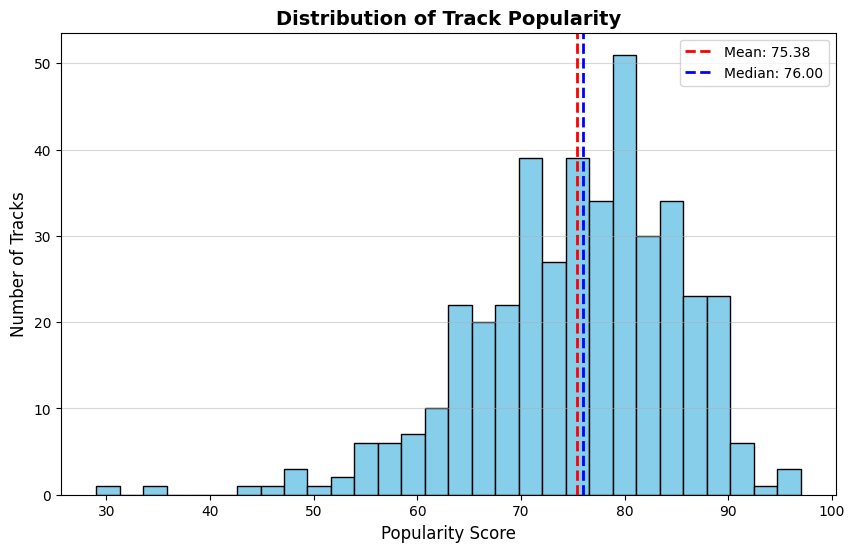

In [11]:

plt.figure(figsize = (10,6))
plt.hist(df['Popularity'],bins=30,color = 'skyblue',edgecolor = 'black')
plt.axvline(mean_pop, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_pop:.2f}')
plt.axvline(median_pop, color='blue', linestyle='dashed', linewidth=2, label=f'Median: {median_pop:.2f}')
plt.title("Distribution of Track Popularity", fontsize=14, weight='bold')
plt.xlabel("Popularity Score", fontsize=12)
plt.ylabel("Number of Tracks", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

In [12]:
#Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot

In [13]:
correlation = df['Duration (ms)'].corr(df['Popularity'])
print("Correlation between duration and popularity:", correlation)


Correlation between duration and popularity: 0.03899200928439096


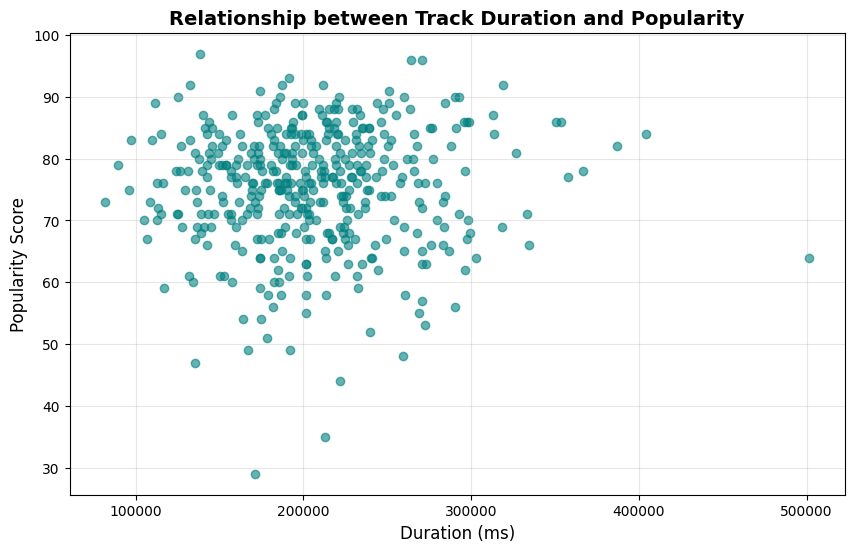

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df['Duration (ms)'],df['Popularity'],color='teal',alpha=0.6)

plt.title('Relationship between Track Duration and Popularity',fontsize=14,weight = 'bold')
plt.xlabel("Duration (ms)", fontsize=12)
plt.ylabel("Popularity Score", fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

The correlation between track duration and popularity is 0.0389, indicating a very weak positive relationship.
The scatter plot shows that the data points are widely spread with no clear trend.
This suggests that the duration of a track does not have a meaningful impact on its popularity in the dataset.

In [15]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID'], dtype='object')

Artist
Drake           17
Eminem          11
Lil Nas X       10
JAY-Z           10
21 Savage       10
Flo Rida        10
¥$              10
Timbaland       10
Ludacris        10
Travis Scott     9
Name: count, dtype: int64


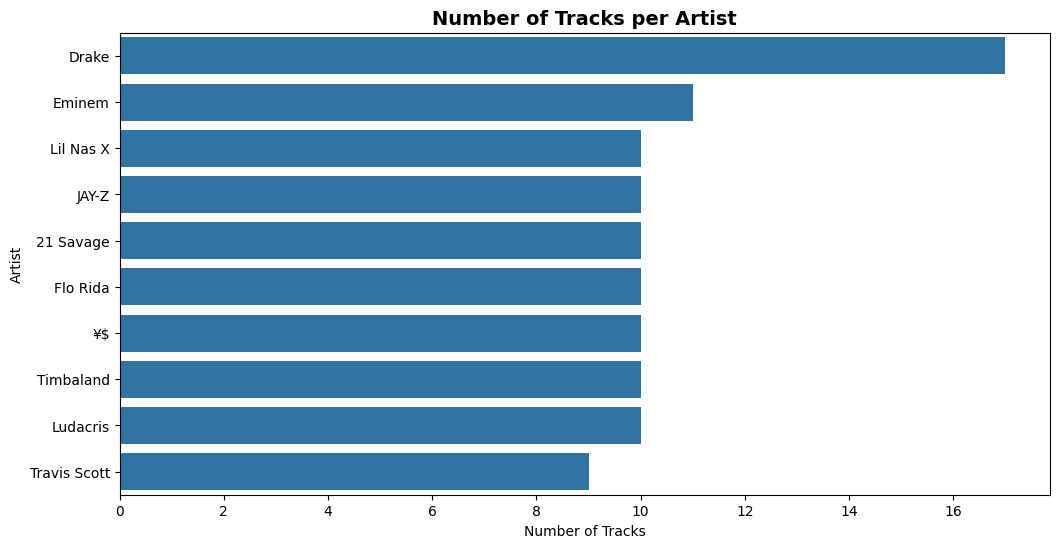

In [16]:
#Which artist has the highest number of tracks in the dataset?
#Display the count of tracks for each artist using a countplot
print(top10_df:=df['Artist'].value_counts().head(10))

plt.figure(figsize=(12,6))
sns.countplot(y='Artist', data=df[df['Artist'].isin(top10_df.index)], order=top10_df.index)

plt.title("Number of Tracks per Artist", fontsize=14, weight='bold')
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")
plt.show()

In [17]:
#What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each
df[['Artist', 'Track Name', 'Popularity']].sort_values(by='Popularity').head()

,Artist,Track Name,Popularity
207,Pressa,Attachments (feat. Coi Leray),29
231,Justin Bieber,Intentions,35
413,French Montana,Splash Brothers,44
225,Lil Baby,On Me - Remix,47
407,Wyclef Jean,911 (feat. Mary J. Blige),48


In [18]:
# Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and 
#display the average popularity for each artist

In [19]:
#“Sometimes the popularity of one song (max) is greater than the average popularity.”
# so i have choosen max
artist_max_popularity = df.groupby('Artist')['Popularity'].max()
top_5_artists = artist_max_popularity.sort_values(ascending=False).head()
top_5 = df[df['Artist'].isin(top_5_artists.index)]
top5_avg = (top_5.groupby('Artist')['Popularity'].mean()).sort_values(ascending=False)
print("Top 5 most popular artists (based on max popularity):")
print(top_5_artists)
print("\nAverage popularity of those artists:")
print(top5_avg)
print("the artist with highest popularity is :")
print(top5_avg.head(1))

Top 5 most popular artists (based on max popularity):
Artist
Jack Harlow     97
21 Savage       96
¥$              96
Travis Scott    93
cassö           92
Name: Popularity, dtype: int64

Average popularity of those artists:
Artist
cassö           92.000000
Travis Scott    86.555556
¥$              85.100000
21 Savage       83.800000
Jack Harlow     77.714286
Name: Popularity, dtype: float64
the artist with highest popularity is :
Artist
cassö    92.0
Name: Popularity, dtype: float64


In [20]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID'], dtype='object')

In [21]:
# For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist
most_popular_tracks = top_5.loc[
    top_5.groupby('Artist')['Popularity'].idxmax(),
    ['Artist', 'Track Name', 'Popularity']
]

print(most_popular_tracks)


           Artist                  Track Name  Popularity
70      21 Savage                      redrum          96
40    Jack Harlow                 Lovin On Me          97
30   Travis Scott  FE!N (feat. Playboi Carti)          93
140         cassö                       Prada          92
260            ¥$                    CARNIVAL          96


<Figure size 1000x800 with 0 Axes>

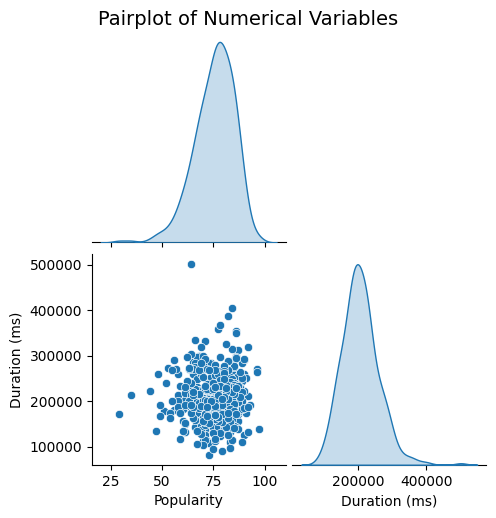

In [27]:
# Visualize relationships between multiple numerical variables simultaneously using a pair plot
num_df = df.select_dtypes(include = ['int','float'])
plt.figure(figsize = (10,8))
sns.pairplot(num_df,diag_kind = 'kde',corner =True)
plt.suptitle("Pairplot of Numerical Variables", y=1.02, fontsize=14)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

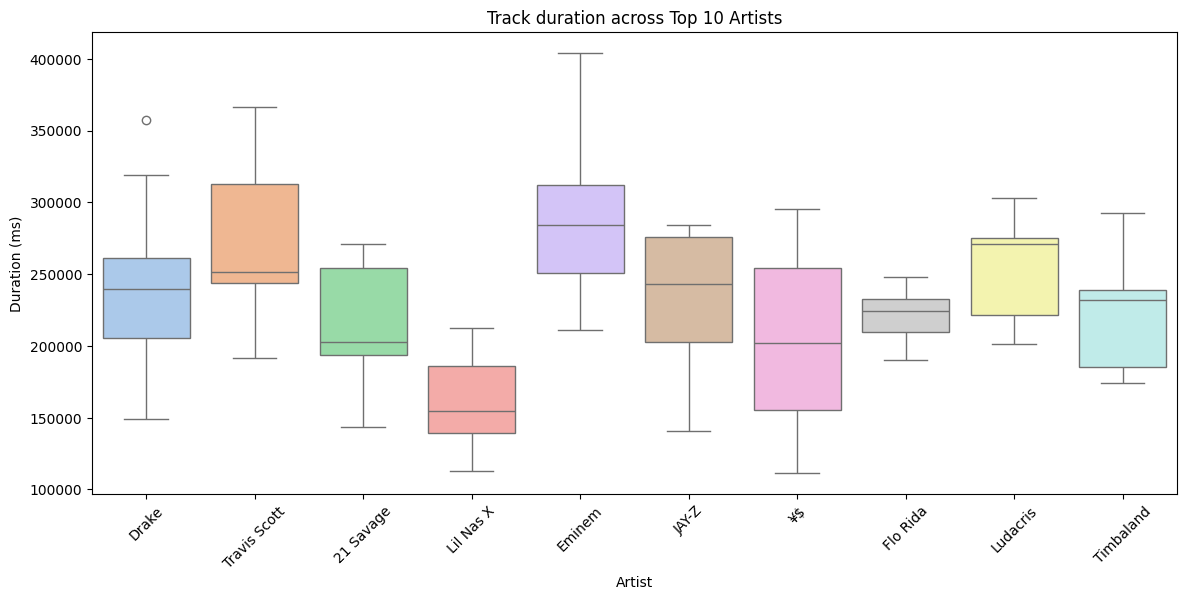

In [39]:
# Does the duration of tracks vary significantly across different artists? 
#Explore this visually using a box plot or  violin plot
top10_artists = df['Artist'].value_counts().head(10).index
df_top10 = df[df['Artist'].isin(top10_artists)]

plt.figure(figsize = (14,6))
sns.boxplot(data=df_top10,x='Artist',y='Duration (ms)',palette ='pastel')
plt.xticks(rotation = 45)
plt.title('Track duration across Top 10 Artists')
plt.show

In [31]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Duration (ms)', 'Track ID'], dtype='object')

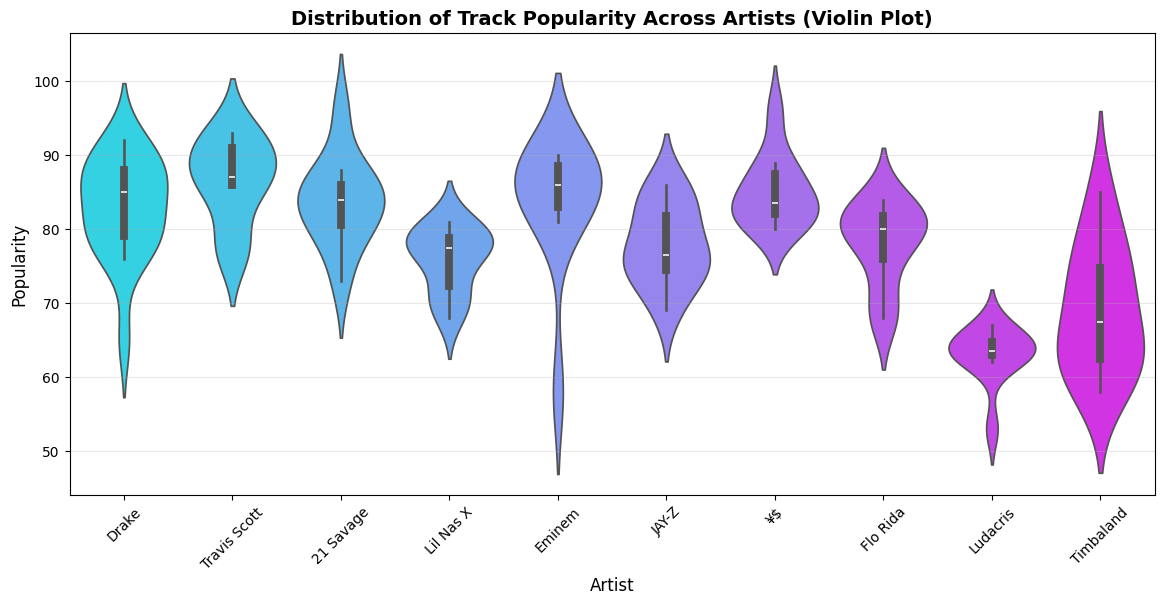

In [40]:
# How does the distribution of track popularity vary for different artists? 
#Visualize this using a swarm plot or a  violin plot
plt.figure(figsize=(14,6))
sns.violinplot(data=df_top10, x='Artist', y='Popularity', palette='cool')

plt.title("Distribution of Track Popularity Across Artists (Violin Plot)", fontsize=14, weight='bold')
plt.xlabel("Artist", fontsize=12)
plt.ylabel("Popularity", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()
